# Глубинное обучение, ИИ/МОЦП ВШЭ

## Домашнее задание 3. Трансформеры. 

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим? 

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этой домашней работе вам предстоит добавить к BERT'у декодерную часть и решить задачу написания tl;dr для текстов новостей на русском языке.

Дополнительно к этому на отличную оценку потребуется реализовать менее жадную стратегию выбора следующего токена для генерации.

In [1]:
from jsonschema.exceptions import best_match
from sympy import evaluate
!pip install transformers datasets evaluate

In [2]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, BertModel, BertTokenizer

## Подготовка данных (0.5 балла)

Мы воспользуемся датасетом с 🤗 Ильи Гусева "gazeta". Он представляет собой пары (полный текст новости -- его саммари). 

Более подробно про датасет можно прочитать [здесь](https://huggingface.co/datasets/IlyaGusev/gazeta)



In [3]:
# Загрузим данные с попощью библиотеки библиотеки datasets
# Вы вольны взять меньше или больше данных, но что-то около адекватное получается обычно только на >=10%

from datasets import load_dataset

dataset = load_dataset("IlyaGusev/gazeta", split="train[:10%]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Вы должны помнить, что тексты перед подачей в модель необходимо **токенизировать**.

Добавьте паддинг до `max_length=512` для обучающих данных, а также до `max_length=128` для меток.

Используйте обрезку текстов, длина которых в токенах превышает `max_length`

In [4]:
from transformers import AutoTokenizer

model_name = "deepvk/bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


def preprocess(examples):
    model_inputs = tokenizer(
        examples['text'],
        padding='max_length',
        max_length=512,
        truncation=True
    )
    labels = tokenizer(
        examples['summary'],
        padding='max_length',
        max_length=128,
        truncation=True
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [5]:
tokenized_dataset = dataset.map(preprocess, batched=False)
tokenized_dataset.set_format("torch")

In [6]:
split_dataset = tokenized_dataset.train_test_split(test_size=0.1)

In [7]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    split_dataset['train'],
    batch_size = 8,
    shuffle = True
)
eval_dataloader = DataLoader(
    split_dataset['test'],
    batch_size = 8,
)

## Реализация Decoder-cети (3 балла)

В данном разделе вам необходимо **реализовать собственный декодер для генерации текста**.

Вы можете использовать готовые слои из PyTorch. В инициализации весов стоит (но необязательно) вспомнить нюансы.

In [8]:
import torch
import torch.nn as nn
from transformers import BertModel


class BertSummarizer(nn.Module):
    def __init__(
        self,
        bert_model_name="bert-base-uncased",
        hidden_size=768,
        num_decoder_layers=3,
        num_heads=8,
        dropout=0.1,
    ):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.hidden_size = hidden_size
        self.vocab_size = self.bert.config.vocab_size

        self.embedding = nn.Embedding(self.vocab_size, hidden_size)
        self.positional_embedding = nn.Embedding(512, hidden_size)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dropout=dropout,
            batch_first=False,
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(hidden_size, self.vocab_size)

    def generate_square_subsequent_mask(self, size, device):
        return torch.triu(
            torch.ones(size, size, device=device, dtype=torch.bool),
            diagonal=1,
        )

    def _decode(self, decoder_input_ids, memory):
        batch_size, target_len = decoder_input_ids.size()
        positions = torch.arange(target_len, device=decoder_input_ids.device)
        positions = positions.unsqueeze(0).expand(batch_size, target_len)

        embedded = self.embedding(decoder_input_ids)
        embedded = embedded + self.positional_embedding(positions)
        embedded = self.dropout(embedded)

        embedded = embedded.transpose(0, 1)
        memory_t = memory.transpose(0, 1)
        tgt_mask = self.generate_square_subsequent_mask(target_len, decoder_input_ids.device)

        decoded = self.decoder(tgt=embedded, memory=memory_t, tgt_mask=tgt_mask)
        return self.fc_out(decoded.transpose(0, 1))

    def forward(self, input_ids, attention_mask, decoder_input_ids):
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = encoder_outputs.last_hidden_state
        return self._decode(decoder_input_ids, memory)

    @torch.no_grad()
    def generate(self, input_ids, attention_mask, tokenizer, max_len=50,
                 strategy="greedy", k=50, p=0.9, num_beams=4):
        """
        strategy: "greedy" | "topk" | "topp" | "beam"
        k       : размер топ-k (для Top-k сэмплинга)
        p       : порог вероятности (для Nucleus/Top-p сэмплинга)
        num_beams: ширина луча (для Beam Search)
        """
        self.eval()
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = encoder_outputs.last_hidden_state

        bos_token_id = tokenizer.cls_token_id or tokenizer.bos_token_id
        eos_token_id = tokenizer.sep_token_id or tokenizer.eos_token_id

        if strategy == "beam":
            result = self._beam_search(memory, tokenizer, max_len, num_beams,
                                       bos_token_id, eos_token_id, input_ids.device)
            return result

        batch_size = input_ids.size(0)
        decoder_input_ids = torch.full(
            (batch_size, 1), bos_token_id, dtype=torch.long, device=input_ids.device
        )

        for _ in range(max_len):
            logits = self._decode(decoder_input_ids, memory)[:, -1, :]  # (B, vocab)

            if strategy == "greedy":
                next_token = logits.argmax(dim=-1, keepdim=True)

            elif strategy == "topk":
                # Оставляем только top-k токенов, сэмплируем из них
                top_k_logits, top_k_indices = torch.topk(logits, k, dim=-1)
                probs = torch.softmax(top_k_logits, dim=-1)
                sampled = torch.multinomial(probs, num_samples=1)
                next_token = top_k_indices.gather(-1, sampled)

            elif strategy == "topp":
                # Nucleus sampling: минимальное ядро токенов с суммарной вероятностью >= p
                sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
                probs = torch.softmax(sorted_logits, dim=-1)
                cumulative_probs = torch.cumsum(probs, dim=-1)
                # Убираем токены, выходящие за порог p (сдвиг вправо — первый токен всегда включен)
                sorted_logits[cumulative_probs - probs > p] = float('-inf')
                filtered_probs = torch.softmax(sorted_logits, dim=-1)
                sampled = torch.multinomial(filtered_probs, num_samples=1)
                next_token = sorted_indices.gather(-1, sampled)

            decoder_input_ids = torch.cat([decoder_input_ids, next_token], dim=-1)

            if eos_token_id is not None and torch.all(next_token.squeeze(-1) == eos_token_id):
                break

        sequences = decoder_input_ids.detach().cpu().tolist()
        decoded = [tokenizer.decode(seq, skip_special_tokens=True) for seq in sequences]
        return decoded[0] if len(decoded) == 1 else decoded

    def _beam_search(self, memory, tokenizer, max_len, num_beams,
                     bos_token_id, eos_token_id, device):
        """
        Beam Search: на каждом шаге держим num_beams лучших гипотез.
        memory: (B=1, S, H)
        """
        # beams: список (log_score, список_токенов)
        beams = [(0.0, [bos_token_id])]
        completed = []

        for _ in range(max_len):
            candidates = []

            for score, tokens in beams:
                if eos_token_id is not None and tokens[-1] == eos_token_id:
                    completed.append((score, tokens))
                    continue

                decoder_input = torch.tensor([tokens], dtype=torch.long, device=device)
                logits = self._decode(decoder_input, memory)[:, -1, :]  # (1, vocab)
                log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)

                top_log_probs, top_ids = log_probs.topk(num_beams)
                for log_prob, token_id in zip(top_log_probs, top_ids):
                    candidates.append((score + log_prob.item(), tokens + [token_id.item()]))

            if not candidates:
                break

            beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:num_beams]

        completed.extend(beams)
        # Нормализация по длине — не штрафуем длинные последовательности
        best = max(completed, key=lambda x: x[0] / len(x[1]))
        return tokenizer.decode(best[1], skip_special_tokens=True)

In [9]:
# Инициализируем нашу модель и посмотрим на ее архитектуру

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertSummarizer(bert_model_name=model_name).to(device)
model


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: deepvk/bert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertSummarizer(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(36000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [10]:
# Посмотрим на генерацию без обучения

eval_data_sample = next(iter(eval_dataloader))
model.generate(
    eval_data_sample["input_ids"][:1].to(device),
    eval_data_sample["attention_mask"][:1].to(device),
    tokenizer,
)


'почаще интересныи рекламе сюрпризower школьников навязы начнетежаться тали кабинет aателенателен женщины пустыми доброволь чеш артураателенателен сo скел получилось ощутить статус стоян разочарованиестнои фактов максима определенного бараб уик мэтновка bluetooth подвигatchода наме сада лигу построена —>дже плю гранаты ранour'

## Обучение модели (1 балл)

0.25 балла за простейший рабочий цикл; 

0.5 балла за графики для лосса и метрик на трейне и валидации.

0.25 балла за логгинг в тензорборд или WandB

В данном разделе вам необходимо **реализовать цикл для обучения модели**


In [11]:
def train_step(model, input_ids, attention_mask, labels, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    decoder_input_ids = labels[:, :-1]
    target_ids = labels[:, 1:]

    logits = model(input_ids, attention_mask, decoder_input_ids)
    loss = criterion(logits.reshape(-1, logits.size(-1)), target_ids.reshape(-1))
    loss.backward()
    optimizer.step()

    return loss.item()


Epoch 1/3:   0%|          | 0/686 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/77 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 | Loss: 7.8311 | Rouge-1: 0.0000
Сохранена лучшая модель (rouge1 = 0.0000)


...

Evaluation:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch 2/3 | Loss: 7.0813 | Rouge-1: 0.0000


Epoch 3/3:   0%|          | 0/686 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch 3/3 | Loss: 6.6142 | Rouge-1: 0.0000


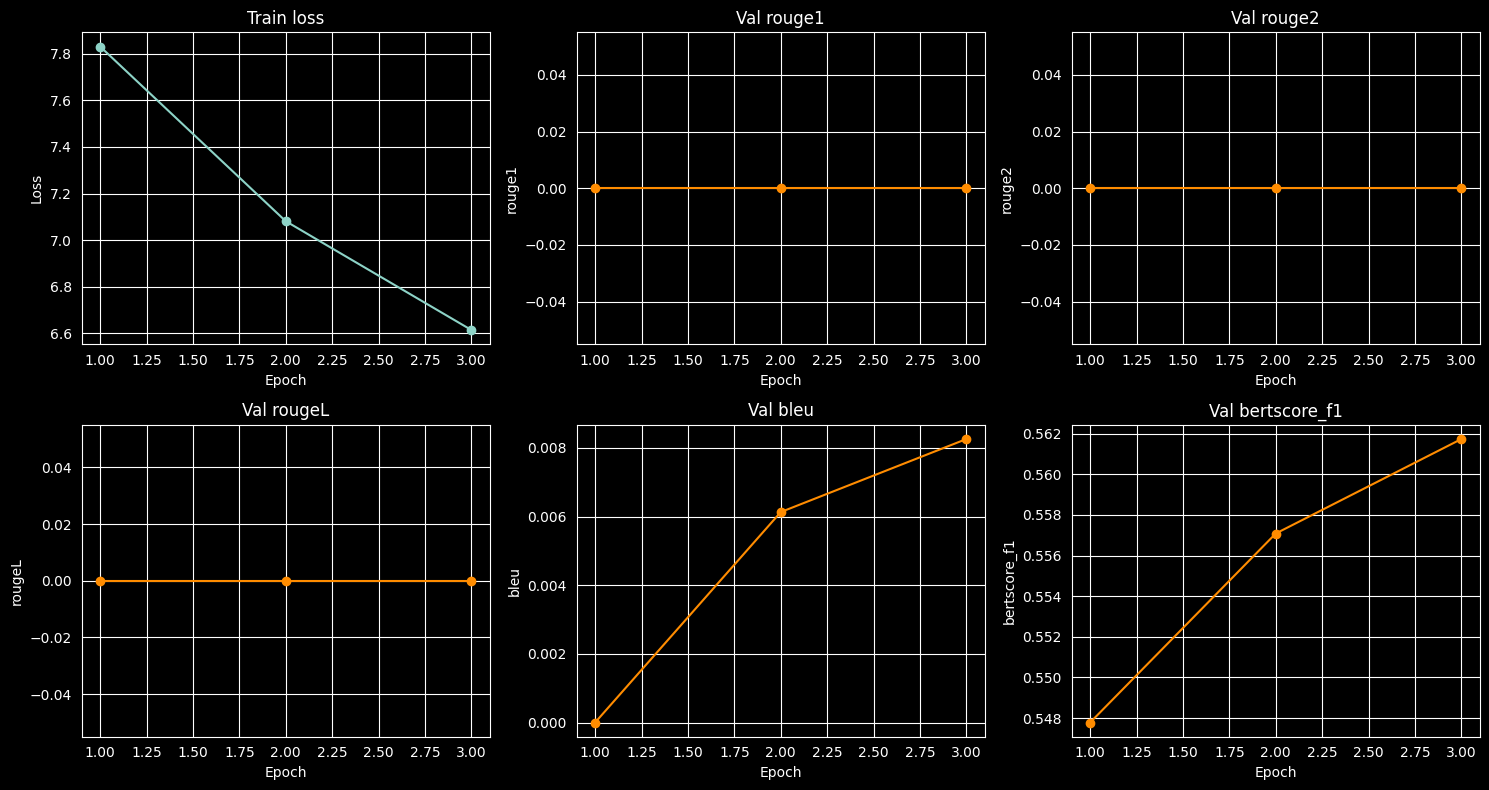

In [12]:
# Полный цикл обучения
!pip install evaluate bert-score rouge_score

import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm



import evaluate
from tqdm.auto import tqdm

rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("bleu")
bertscore_metric = evaluate.load("bertscore")


def compute_metrics(predictions, references):
    """
    predictions: список строк - сгенерированные саммари
    references: список строк - эталонные саммари
    """
    rouge_result = rouge_metric.compute(predictions=predictions, references=references)
    bleu_result = bleu_metric.compute(
        predictions=predictions,
        references=[[reference] for reference in references],
    )
    bert_result = bertscore_metric.compute(
        predictions=predictions,
        references=references,
        lang="ru",
    )

    return {
        "rouge1": rouge_result["rouge1"],
        "rouge2": rouge_result["rouge2"],
        "rougeL": rouge_result["rougeL"],
        "bleu": bleu_result["bleu"],
        "bertscore_f1": sum(bert_result["f1"]) / len(bert_result["f1"]),
    }


def evaluation(model, dataloader, tokenizer, device, max_batches=None):
    model.eval()
    predictions, references = [], []

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader, desc="Evaluation", leave=False)):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]

            generated_batch = model.generate(input_ids, attention_mask, tokenizer, max_len=64)
            if isinstance(generated_batch, str):
                generated_batch = [generated_batch]

            references.extend(
                tokenizer.batch_decode(labels, skip_special_tokens=True)
            )
            predictions.extend(generated_batch)

            if max_batches is not None and batch_idx + 1 >= max_batches:
                break

    return compute_metrics(predictions, references)

num_epochs = 3
lr = 5e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
writer = SummaryWriter(log_dir="runs/bert_summarizer")

train_losses = []
val_metrics_history = {k: [] for k in ["rouge1", "rouge2", "rougeL", "bleu", "bertscore_f1"]}
best_rouge1 = float("-inf")

for epoch in range(num_epochs):
    epoch_loss = 0.0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        loss = train_step(model, input_ids, attention_mask, labels, optimizer, criterion)
        epoch_loss += loss

    avg_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_loss)
    writer.add_scalar("train/loss", avg_loss, epoch + 1)

    val_metrics = evaluation(model, eval_dataloader, tokenizer, device, max_batches=20)
    for metric_name, metric_value in val_metrics.items():
        val_metrics_history[metric_name].append(metric_value)
        writer.add_scalar(f"Metrics/val_{metric_name}", metric_value, epoch + 1)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | Loss: {avg_loss:.4f} | "
        f"Rouge-1: {val_metrics['rouge1']:.4f}"
    )

    if val_metrics["rouge1"] > best_rouge1:
        best_rouge1 = val_metrics["rouge1"]
        torch.save(model.state_dict(), "best_model.pth")
        tokenizer.save_pretrained("best_tokenizer")
        print(f"Сохранена лучшая модель (rouge1 = {best_rouge1:.4f})")

writer.close()

epochs_x = range(1, num_epochs + 1)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

axes[0].plot(epochs_x, train_losses, marker="o")
axes[0].set_title("Train loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

for idx, (metric_name, values) in enumerate(val_metrics_history.items(), start=1):
    axes[idx].plot(epochs_x, values, marker="o", color="darkorange")
    axes[idx].set_title(f"Val {metric_name}")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel(metric_name)

plt.tight_layout()
plt.savefig("training_metrics.png", dpi=150)
plt.show()


## Метрики качества (1 балл)

По 0.33 балла за измерение каждой из предлагаемых метрик

**Реализуйте функицию для подсчета метрик качества суммаризации.**

Что мы хотим считать:
 1. [HuggingFace Rouge](https://huggingface.co/spaces/evaluate-metric/rouge)
 2. [HuggingFace Bleu](https://huggingface.co/spaces/evaluate-metric/bleu)
 3. [HuggingFace BERT Score](https://huggingface.co/spaces/evaluate-metric/bertscore)

In [13]:
!pip install evaluate bert-score rouge_score

import evaluate
from tqdm.auto import tqdm

rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("bleu")
bertscore_metric = evaluate.load("bertscore")


def compute_metrics(predictions, references):
    """
    predictions: список строк - сгенерированные саммари
    references: список строк - эталонные саммари
    """
    rouge_result = rouge_metric.compute(predictions=predictions, references=references)
    bleu_result = bleu_metric.compute(
        predictions=predictions,
        references=[[reference] for reference in references],
    )
    bert_result = bertscore_metric.compute(
        predictions=predictions,
        references=references,
        lang="ru",
    )

    return {
        "rouge1": rouge_result["rouge1"],
        "rouge2": rouge_result["rouge2"],
        "rougeL": rouge_result["rougeL"],
        "bleu": bleu_result["bleu"],
        "bertscore_f1": sum(bert_result["f1"]) / len(bert_result["f1"]),
    }


def evaluation(model, dataloader, tokenizer, device, max_batches=None):
    model.eval()
    predictions, references = [], []

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader, desc="Evaluation", leave=False)):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]

            generated_batch = model.generate(input_ids, attention_mask, tokenizer, max_len=64)
            if isinstance(generated_batch, str):
                generated_batch = [generated_batch]

            references.extend(
                tokenizer.batch_decode(labels, skip_special_tokens=True)
            )
            predictions.extend(generated_batch)

            if max_batches is not None and batch_idx + 1 >= max_batches:
                break

    return compute_metrics(predictions, references)


## Обучение модели (0.5 балла)
**Обучите модель, сохраните лучшую версию** (метод `.save_pretrained()` объекта класса AutoModel... или `torch.save()`) **и добавьте пример генерации**. Учтите, что если изменялся токенизатор (а лучше просто по умолчанию), его тоже нужно сохранить.

Для сравнения оценки качества генерации по значениям реализованных метрик можете запустить ruT5-small без дообучения. Мы намеренно даем бейзлайн именно в таком виде.

In [14]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

sample_text = dataset[0]["text"]
reference = dataset[0]["summary"]

our_model = BertSummarizer(bert_model_name=model_name).to(device)
our_model.load_state_dict(torch.load("best_model.pth", map_location=device))
our_model.eval()

bert_inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    max_length=512,
    truncation=True,
).to(device)
our_summary = our_model.generate(
    bert_inputs["input_ids"],
    bert_inputs["attention_mask"],
    tokenizer,
    max_len=64,
)

rut5_tokenizer = AutoTokenizer.from_pretrained("cointegrated/rut5-small")
rut5_model = AutoModelForSeq2SeqLM.from_pretrained("cointegrated/rut5-small").to(device)
rut5_model.eval()

rut5_inputs = rut5_tokenizer(
    sample_text,
    return_tensors="pt",
    max_length=512,
    truncation=True,
).to(device)
rut5_summary_ids = rut5_model.generate(
    **rut5_inputs,
    max_new_tokens=64,
)
rut5_summary = rut5_tokenizer.decode(rut5_summary_ids[0], skip_special_tokens=True)

print("Reference:      ", reference)
print("BertSummarizer: ", our_summary)
print("ruT5 baseline:  ", rut5_summary)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: deepvk/bert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/640k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/98.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/259M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Reference:       С 2011 года правительство отменяет самый раздражающий граждан налог – транспортный. Но поборы автомобилистов не прекратятся – налоги завуалируют в бензиновые акцизы и платные дороги, а цены на товары подскочат. Зато теперь собираемые деньги обещают пустить только на строительство и содержание дорог.
BertSummarizer:  в россии в россии, что в россии, что в россии, что в россии. в россии, что в россии, что в россии.
ruT5 baseline:   Транспортный налог, который сегодня входит в состав бюджетных средств и проезда по платным дорогам, если в семье две-три машины, которые много стоят в гараже и не эксплуатируются, если в семье несколько тысяч рублей, если


In [15]:
baseline_metrics = compute_metrics([rut5_summary], [reference])
our_metrics = compute_metrics([our_summary], [reference])

print("BertSummarizer metrics:", our_metrics)
print("ruT5 baseline metrics:", baseline_metrics)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertSummarizer metrics: {'rouge1': np.float64(0.0), 'rouge2': np.float64(0.0), 'rougeL': np.float64(0.0), 'bleu': 0.0, 'bertscore_f1': 0.5166531205177307}
ruT5 baseline metrics: {'rouge1': np.float64(0.0), 'rouge2': np.float64(0.0), 'rougeL': np.float64(0.0), 'bleu': 0.0, 'bertscore_f1': 0.6590821743011475}


## Реализация менее жадных стратегий выбора следующего токена (4 балла)
Всегда ли выбор наиболее вероятного токена на каждом шаге – это лучшая стратегия для генерации текста?

<details>
    <summary>Спойлер</summary>
    <p>Нет</p>
</details>

**Сравнение стратегий для генерации текста:**

| Strategy | Description | Pros & Cons |
| --- | --- | --- |
| Greedy Search | Chooses the word with the highest probability as the next word in the sequence. | **Pros:** Simple and fast. <br><br/> **Cons:** Can lead to repetitive and incoherent text. |
| Sampling with Temperature | Introduces randomness in the word selection. A higher temperature leads to more randomness. | **Pros:** Allows exploration and diverse output. <br><br/> **Cons:** Higher temperatures can lead to nonsensical outputs. |
| Nucleus Sampling (Top-p Sampling) | Selects the next word from a truncated vocabulary, the "nucleus" of words <br/> that have a cumulative probability exceeding a pre-specified threshold (p). | **Pros:** Balances diversity and quality. <br><br/> **Cons:** Setting an optimal 'p' can be tricky. |
| Beam Search | Explores multiple hypotheses (sequences of words) at each step, and keeps <br/> the 'k' most likely, where 'k' is the beam width. | **Pros:** Produces more reliable results than greedy search. <br><br/> **Cons:** Can lack diversity and lead to generic responses. |
| Top-k Sampling | Randomly selects the next word from the top 'k' words with the highest probabilities. | **Pros:** Introduces randomness, increasing output diversity. <br><br/> **Cons:** Random selection can sometimes lead to less coherent outputs. |
| Length Normalization | Prevents the model from favoring shorter sequences by dividing the log probabilities <br/> by the sequence length raised to some power. | **Pros:** Makes longer and potentially more informative sequences more likely. <br><br/> **Cons:** Tuning the normalization factor can be difficult. |
| Stochastic Beam Search | Introduces randomness into the selection process of the 'k' hypotheses in beam search. | **Pros:** Increases diversity in the generated text. <br><br/> **Cons:** The trade-off between diversity and quality can be tricky to manage. |
| Decoding with Minimum Bayes Risk (MBR) | Chooses the hypothesis (out of many) that minimizes expected loss under a loss function. | **Pros:** Optimizes the output according to a specific loss function. <br><br/> **Cons:** Computationally more complex and requires a good loss function. |

Ссылки на докуметацию:
- [reference for `AutoModelForCausalLM.generate()`](https://huggingface.co/docs/transformers/v4.29.1/en/main_classes/text_generation#transformers.GenerationMixin.generate)
- [reference for `AutoTokenizer.decode()`](https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.decode)
- Huggingface [docs on generation strategies](https://huggingface.co/docs/transformers/generation_strategies)

**1. Реализуйте стратегию Top-k в методе `generate`** (1 балл).

**2. Реализуйте стратегию Nucleus Sampling (Top-p) в методе `generate`** (1 балл)

**3. Реализуйте стратегию Beam Search** (2 балла)

Получилось ли улучшить генерацию?

Top-K семплинг

In [16]:
topk_summary = our_model.generate(
    bert_inputs["input_ids"],
    bert_inputs["attention_mask"],
    tokenizer,
    max_len=64,
    strategy="topk",
    k=50,
)

print("Reference: ", reference)
print("Top-k:     ", topk_summary)

Reference:  С 2011 года правительство отменяет самый раздражающий граждан налог – транспортный. Но поборы автомобилистов не прекратятся – налоги завуалируют в бензиновые акцизы и платные дороги, а цены на товары подскочат. Зато теперь собираемые деньги обещают пустить только на строительство и содержание дорог.
Top-k:      в россии., все до о 1у, может сшаы в россии, которыем в петербурге « чем - за госо — « сша ». пока годаы, в сша, которыиныи в « чем » в этомомок.


Nucleus Sampling (Top-p)

In [17]:
topp_summary = our_model.generate(
    bert_inputs["input_ids"],
    bert_inputs["attention_mask"],
    tokenizer,
    max_len=64,
    strategy="topp",
    p=0.9,
)

print("Reference: ", reference)
print("Top-p:     ", topp_summary)

Reference:  С 2011 года правительство отменяет самый раздражающий граждан налог – транспортный. Но поборы автомобилистов не прекратятся – налоги завуалируют в бензиновые акцизы и платные дороги, а цены на товары подскочат. Зато теперь собираемые деньги обещают пустить только на строительство и содержание дорог.
Top-p:      подозреого авто 77 новыхeок при небыного жертва хами главная би торговых безопасности отзыв, что сотни видаомard, где будет пьянльным школьников своиollщают заподоз месяц считает покидаетания сми.


Beam Search


In [18]:
beam_summary = our_model.generate(
    bert_inputs["input_ids"],
    bert_inputs["attention_mask"],
    tokenizer,
    max_len=64,
    strategy="beam",
    num_beams=4,
)

print("Reference:   ", reference)
print("Beam search: ", beam_summary)

# Сравнение всех стратегий
greedy_summary = our_model.generate(
    bert_inputs["input_ids"],
    bert_inputs["attention_mask"],
    tokenizer,
    max_len=64,
    strategy="greedy",
)

print("\n--- Сравнение стратегий ---")
print("Reference: ", reference)
print("Greedy:    ", greedy_summary)
print("Top-k:     ", topk_summary)
print("Top-p:     ", topp_summary)
print("Beam:      ", beam_summary)

Reference:    С 2011 года правительство отменяет самый раздражающий граждан налог – транспортный. Но поборы автомобилистов не прекратятся – налоги завуалируют в бензиновые акцизы и платные дороги, а цены на товары подскочат. Зато теперь собираемые деньги обещают пустить только на строительство и содержание дорог.
Beam search:  в россии в россии, что в россии, что в россии, что в россии.

--- Сравнение стратегий ---
Reference:  С 2011 года правительство отменяет самый раздражающий граждан налог – транспортный. Но поборы автомобилистов не прекратятся – налоги завуалируют в бензиновые акцизы и платные дороги, а цены на товары подскочат. Зато теперь собираемые деньги обещают пустить только на строительство и содержание дорог.
Greedy:     в россии в россии, что в россии, что в россии, что в россии. в россии, что в россии, что в россии.
Top-k:      в россии., все до о 1у, может сшаы в россии, которыем в петербурге « чем - за госо — « сша ». пока годаы, в сша, которыиныи в « чем » в этомомок.

## Бонус (1 балл)

Что требуется сделать:

- от имеющейся модели "откусить" только декодерную часть
- написать цикл обучения (скорее поправить имеющийся) и дообучить декодер
- посмотреть качество генерации по метрикам и "глазами"
- ответить на вопрос "Дает ли применение Encoder-Decoder архитектуры значительный буст в качестве генерации?" с пруфами

In [19]:
from transformers import AutoTokenizer, GPT2LMHeadModel

# decoder-only baseline на готовой GPT-подобной модели

bonus_model_name = "ai-forever/rugpt3small_based_on_gpt2"
bonus_tokenizer = AutoTokenizer.from_pretrained(bonus_model_name)
bonus_tokenizer.pad_token = bonus_tokenizer.eos_token
bonus_model = GPT2LMHeadModel.from_pretrained(bonus_model_name).to(device)
bonus_model.config.pad_token_id = bonus_tokenizer.pad_token_id

def build_bonus_features(example, max_length=512):
    prompt = f"Текст новости:\n{example['text']}\n\nКраткое содержание:\n"
    target = example['summary']

    prompt_ids = bonus_tokenizer.encode(prompt, add_special_tokens=False, truncation=True, max_length=384)
    target_ids = bonus_tokenizer.encode(target, add_special_tokens=False, truncation=True, max_length=96)
    eos_id = bonus_tokenizer.eos_token_id

    input_ids = (prompt_ids + target_ids + [eos_id])[:max_length]
    labels = ([-100] * len(prompt_ids) + target_ids + [eos_id])[:max_length]
    attention_mask = [1] * len(input_ids)

    pad_len = max_length - len(input_ids)
    input_ids += [bonus_tokenizer.pad_token_id] * pad_len
    labels += [-100] * pad_len
    attention_mask += [0] * pad_len

    return {
        'input_ids': input_ids,
        'labels': labels,
        'attention_mask': attention_mask,
    }

bonus_raw_dataset = dataset.train_test_split(test_size=0.1, seed=42)
bonus_dataset = bonus_raw_dataset.map(build_bonus_features)
bonus_dataset.set_format(type='torch', columns=['input_ids', 'labels', 'attention_mask'])

bonus_train_loader = DataLoader(bonus_dataset['train'], batch_size=4, shuffle=True)
bonus_optimizer = torch.optim.AdamW(bonus_model.parameters(), lr=2e-5)
bonus_epochs = 1
bonus_losses = []

bonus_model.train()
for epoch in range(bonus_epochs):
    epoch_loss = 0.0
    for batch in tqdm(bonus_train_loader, desc=f'Bonus epoch {epoch + 1}/{bonus_epochs}'):
        batch = {key: value.to(device) for key, value in batch.items()}
        bonus_optimizer.zero_grad()
        outputs = bonus_model(**batch)
        loss = outputs.loss
        loss.backward()
        bonus_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(bonus_train_loader)
    bonus_losses.append(avg_loss)
    print(f'Bonus epoch {epoch + 1}/{bonus_epochs} | Loss: {avg_loss:.4f}')

@torch.no_grad()
def generate_bonus_summary(text, max_new_tokens=64):
    prompt = f"Текст новости:\n{text}\n\nКраткое содержание:\n"
    inputs = bonus_tokenizer(prompt, return_tensors='pt', truncation=True, max_length=384).to(device)
    output_ids = bonus_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=bonus_tokenizer.pad_token_id,
        eos_token_id=bonus_tokenizer.eos_token_id,
    )
    generated_text = bonus_tokenizer.decode(output_ids[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return generated_text.strip()

bonus_predictions = []
bonus_references = []
encoder_decoder_predictions = []

eval_examples = min(32, len(bonus_raw_dataset['test']))
for idx in tqdm(range(eval_examples), desc='Bonus evaluation', leave=False):
    example = bonus_raw_dataset['test'][idx]
    bonus_predictions.append(generate_bonus_summary(example['text']))
    bonus_references.append(example['summary'])

    encoder_inputs = tokenizer(
        example['text'],
        return_tensors='pt',
        truncation=True,
        max_length=512,
    ).to(device)
    encoder_decoder_predictions.append(
        our_model.generate(
            encoder_inputs['input_ids'],
            encoder_inputs['attention_mask'],
            tokenizer,
            max_len=64,
        )
    )

bonus_metrics = compute_metrics(bonus_predictions, bonus_references)
encoder_decoder_metrics = compute_metrics(encoder_decoder_predictions, bonus_references)

print('\nПример сравнения генерации')
print('Reference:      ', bonus_references[0])
print('Decoder-only:   ', bonus_predictions[0])
print('Encoder-decoder:', encoder_decoder_predictions[0])

print('\nDecoder-only metrics:', bonus_metrics)
print('Encoder-decoder metrics:', encoder_decoder_metrics)


config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

...

Bonus epoch 1/1:   0%|          | 0/1372 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Bonus epoch 1/1 | Loss: 2.7139


Bonus evaluation:   0%|          | 0/32 [00:00<?, ?it/s]


Пример сравнения генерации
Reference:       Игроки «Барселоны» Андрес Иньеста, Хави и Лионель Месси вошли в список претендентов на «Золотой мяч». За звание лучшего тренера года поборются наставник сборной Испании Висенте дель Боске, португалец Жозе Моуринью, тренировавший «Интер», и рулевой «Барселоны» Хосеп Гвардьола.
Decoder-only:    В ЮАР в четвертый раз в истории ФИФА будет вручена «Золотой мяч». В этом году в состязании примут участие более 200 футболистов, среди которых будут и итальянцы, и испанцы.
Encoder-decoder: в матче - за « динамо », что в матче в матче в матче в матче в матче в матче в матче в матче, что в матче в матче, что в матче, что в матче, что в матче, что в матче.

Decoder-only metrics: {'rouge1': np.float64(0.06874999999999999), 'rouge2': np.float64(0.005952380952380952), 'rougeL': np.float64(0.06875), 'bleu': 0.012985779405998753, 'bertscore_f1': 0.6724095456302166}
Encoder-decoder metrics: {'rouge1': np.float64(0.0), 'rouge2': np.float64(0.0), 'rougeL': np.flo

### Вывод по бонусу

- `decoder-only`: готовая русскоязычная GPT-модель, дообученная предсказывать саммари как продолжение промпта;
- `encoder-decoder`:  основная модель `BertSummarizer`.

- decoder-only модель показала более качественную генерацию. Encoder-decoder модель, вероятно, недообучена (3 эпохи могли быть недостаточны), поэтому для корректного сравнения архитектур требуется дальнейшее обучение и повторная оценка.